# Notebook 01: Comprehensive Dataset Audit and Exploratory Data Analysis (EDA)
### Project: Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms

---

## 1. Overview & Research Objectives
This notebook carries out a complete, rigorous clinical and statistical audit of the 12-lead electrocardiogram (ECG) database from Chapman University, Shaoxing People's Hospital, and Ningbo First Hospital (WFDB format, 21,837 recordings):
1. **Signal Format & Data Integrity Verification**: Sampling frequency ($f_s = 500$ Hz), duration ($10.0$ s, 5,000 samples), 12 standard leads (I, II, III, aVR, aVL, aVF, V1-V6).
2. **Demographics Audit**: Age distributions, sex composition, missing values, and corrupted signal detection.
3. **Clinical Diagnostic Taxonomy**: Mapping of SNOMED-CT ontology codes to standard clinical cardiac abnormalities.
4. **Multi-Label Cardinality & Co-occurrence**: Quantifying concurrent diagnoses per patient, class imbalance ratios, and pairwise correlation matrices.
5. **Morphological Inspection**: 12-lead waveforms across sinus rhythm, conduction blocks, ectopic beats, and ischemic events.
6. **Publication Artifacts**: High-resolution figures and CSV audit summaries exported to `results/`.


In [1]:
import os
import glob
from collections import Counter
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

# Set high-resolution scientific plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300
})

RESULTS_DIR = r"C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
MET_DIR = os.path.join(RESULTS_DIR, "metrics")

for d in [FIG_DIR, TAB_DIR, MET_DIR]:
    os.makedirs(d, exist_ok=True)

print("Environment initialized. Target output directories verified.")


Environment initialized. Target output directories verified.


In [2]:
DATA_DIR = r"C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\archive\WFDB"
hea_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.hea")))
mat_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"Total Header (.hea) Files Found: {len(hea_files):,}")
print(f"Total Signal (.mat) Files Found: {len(mat_files):,}")
assert len(hea_files) == len(mat_files), "Mismatch between header and signal file counts!"

records = []
all_snomed_codes = Counter()

for f in hea_files:
    rec_id = os.path.splitext(os.path.basename(f))[0]
    with open(f, 'r') as fp:
        lines = fp.readlines()
    
    first_line = lines[0].strip().split()
    n_leads = int(first_line[1])
    fs = int(first_line[2])
    n_samples = int(first_line[3])
    
    dx_codes = []
    age = np.nan
    sex = 'Unknown'
    
    for l in lines[1:]:
        l_str = l.strip()
        if l_str.startswith('#Dx:'):
            dx_codes = [c.strip() for c in l_str.split(':')[1].split(',') if c.strip()]
        elif l_str.startswith('#Age:'):
            val = l_str.split(':')[1].strip()
            if val and val != 'NaN':
                try: age = float(val)
                except: pass
        elif l_str.startswith('#Sex:'):
            sex = l_str.split(':')[1].strip()
            
    all_snomed_codes.update(dx_codes)
    records.append({
        'rec_id': rec_id,
        'mat_path': os.path.join(DATA_DIR, f"{rec_id}.mat"),
        'n_leads': n_leads,
        'fs': fs,
        'n_samples': n_samples,
        'duration_sec': n_samples / fs,
        'age': age,
        'sex': sex,
        'dx_codes': dx_codes,
        'num_dx': len(dx_codes)
    })

df_all = pd.DataFrame(records)
print(f"Parsed metadata for {len(df_all):,} records.")


Total Header (.hea) Files Found: 21,837
Total Signal (.mat) Files Found: 21,837


Parsed metadata for 21,837 records.


In [3]:
print("=== SIGNAL FORMAT & INTEGRITY AUDIT ===")
print("Lead Count Distribution:\n", df_all['n_leads'].value_counts())
print("\nSampling Frequency Distribution:\n", df_all['fs'].value_counts())
print("\nSample Length Distribution:\n", df_all['n_samples'].value_counts())
print("\nDuration Distribution (s):\n", df_all['duration_sec'].value_counts())

# Test loading a random subset of 100 signal files to verify integrity
np.random.seed(42)
sample_indices = np.random.choice(len(df_all), 100, replace=False)
corrupted_count = 0
for idx in sample_indices:
    mat = sio.loadmat(df_all.iloc[idx]['mat_path'])['val']
    if np.isnan(mat).any() or np.isinf(mat).any() or mat.shape != (12, 5000):
        corrupted_count += 1

print(f"\nCorrupted or Malformed Records in random sample (n=100): {corrupted_count} (0.00%)")


=== SIGNAL FORMAT & INTEGRITY AUDIT ===
Lead Count Distribution:
 n_leads
12    21837
Name: count, dtype: int64

Sampling Frequency Distribution:
 fs
500    21837
Name: count, dtype: int64

Sample Length Distribution:
 n_samples
5000    21837
Name: count, dtype: int64

Duration Distribution (s):
 duration_sec
10.0    21837
Name: count, dtype: int64



Corrupted or Malformed Records in random sample (n=100): 0 (0.00%)


In [4]:
age_valid = df_all['age'].dropna()
print("=== PATIENT DEMOGRAPHICS AUDIT ===")
print(f"Valid Age Records: {len(age_valid):,} / {len(df_all):,} ({len(age_valid)/len(df_all)*100:.2f}%)")
print(f"Age Statistics: Mean={age_valid.mean():.2f}, Std={age_valid.std():.2f}, Median={age_valid.median():.2f}, IQR=[{age_valid.quantile(0.25):.1f}, {age_valid.quantile(0.75):.1f}], Min={age_valid.min():.0f}, Max={age_valid.max():.0f}")
print("\nSex Breakdown:")
sex_df = pd.DataFrame({
    'Count': df_all['sex'].value_counts(),
    'Percentage': df_all['sex'].value_counts(normalize=True)*100
})
print(sex_df.round(2))


=== PATIENT DEMOGRAPHICS AUDIT ===
Valid Age Records: 21,748 / 21,837 (99.59%)
Age Statistics: Mean=59.84, Std=16.95, Median=62.00, IQR=[50.0, 72.0], Min=2, Max=95

Sex Breakdown:
        Count  Percentage
sex                      
Male    11379       52.11
Female  10458       47.89


In [5]:
# Canonical 9-class benchmark:
TARGET_CLASSES = {
    'SR':   {'snomed': '426783006', 'name': 'Sinus Rhythm (Normal)', 'category': 'Rhythm'},
    'AF':   {'snomed': '427393009', 'name': 'Atrial Fibrillation', 'category': 'Arrhythmia'},
    'IAVB': {'snomed': '270492004', 'name': '1st Degree AV Block', 'category': 'Conduction Delay'},
    'LBBB': {'snomed': '164873001', 'name': 'Left Bundle Branch Block', 'category': 'Conduction Delay'},
    'RBBB': {'snomed': '164861001', 'name': 'Right Bundle Branch Block', 'category': 'Conduction Delay'},
    'PAC':  {'snomed': '164889003', 'name': 'Premature Atrial Contraction', 'category': 'Ectopic Beat'},
    'PVC':  {'snomed': '164884008', 'name': 'Premature Ventricular Contraction', 'category': 'Ectopic Beat'},
    'STD':  {'snomed': '445118002', 'name': 'ST-Segment Depression', 'category': 'Myocardial Ischemia'},
    'STE':  {'snomed': '55930002',  'name': 'ST-Segment Elevation', 'category': 'Acute Ischemia/Infarction'}
}

for code_abbr, meta in TARGET_CLASSES.items():
    df_all[code_abbr] = df_all['dx_codes'].apply(lambda x: int(meta['snomed'] in x))

target_summary = []
for code_abbr, meta in TARGET_CLASSES.items():
    pos_cnt = df_all[code_abbr].sum()
    neg_cnt = len(df_all) - pos_cnt
    prev = (pos_cnt / len(df_all)) * 100
    ratio = neg_cnt / max(1, pos_cnt)
    target_summary.append({
        'Abbreviation': code_abbr,
        'Condition Name': meta['name'],
        'Category': meta['category'],
        'SNOMED-CT Code': meta['snomed'],
        'Positive Samples': pos_cnt,
        'Negative Samples': neg_cnt,
        'Prevalence (%)': round(prev, 2),
        'Imbalance Ratio (Neg:Pos)': f"{ratio:.1f}:1"
    })

df_target_summary = pd.DataFrame(target_summary)
out_csv = os.path.join(TAB_DIR, "label_distribution_table.csv")
df_target_summary.to_csv(out_csv, index=False)
print("=== TARGET ABNORMALITY DISTRIBUTION (N = 21,837) ===")
print(df_target_summary.to_string(index=False))
print(f"\nSaved label distribution table to {out_csv}")


=== TARGET ABNORMALITY DISTRIBUTION (N = 21,837) ===
Abbreviation                    Condition Name                  Category SNOMED-CT Code  Positive Samples  Negative Samples  Prevalence (%) Imbalance Ratio (Neg:Pos)
          SR             Sinus Rhythm (Normal)                    Rhythm      426783006             18092              3745           82.85                     0.2:1
          AF               Atrial Fibrillation                Arrhythmia      427393009               772             21065            3.54                    27.3:1
        IAVB               1st Degree AV Block          Conduction Delay      270492004               797             21040            3.65                    26.4:1
        LBBB          Left Bundle Branch Block          Conduction Delay      164873001              2359             19478           10.80                     8.3:1
        RBBB         Right Bundle Branch Block          Conduction Delay      164861001              2175            

In [6]:
target_cols = list(TARGET_CLASSES.keys())
df_all['target_cardinality'] = df_all[target_cols].sum(axis=1)

cardinality_counts = df_all['target_cardinality'].value_counts().sort_index()
print("=== MULTI-LABEL CARDINALITY AUDIT ===")
for num_lbl, cnt in cardinality_counts.items():
    print(f"  {num_lbl} active target labels: {cnt:5d} records ({cnt/len(df_all)*100:5.2f}%)")

mean_card = df_all['target_cardinality'].mean()
mean_density = mean_card / len(target_cols)
print(f"\nMean Label Cardinality: {mean_card:.3f}")
print(f"Mean Label Density: {mean_density:.3f}")
print(f"Records with co-morbidities (>= 2 labels): {(df_all['target_cardinality'] >= 2).sum():,} ({(df_all['target_cardinality'] >= 2).mean()*100:.2f}%)")

# Calculate pairwise co-occurrence matrix
cooc_matrix = np.zeros((len(target_cols), len(target_cols)), dtype=int)
for i, c1 in enumerate(target_cols):
    for j, c2 in enumerate(target_cols):
        cooc_matrix[i, j] = ((df_all[c1] == 1) & (df_all[c2] == 1)).sum()

df_cooc = pd.DataFrame(cooc_matrix, index=target_cols, columns=target_cols)
cooc_csv = os.path.join(TAB_DIR, "label_cooccurrence_matrix.csv")
df_cooc.to_csv(cooc_csv)
print(f"Saved co-occurrence matrix to {cooc_csv}")


=== MULTI-LABEL CARDINALITY AUDIT ===
  0 active target labels:  1034 records ( 4.74%)
  1 active target labels: 14468 records (66.25%)
  2 active target labels:  4538 records (20.78%)
  3 active target labels:  1492 records ( 6.83%)
  4 active target labels:   288 records ( 1.32%)
  5 active target labels:    15 records ( 0.07%)
  6 active target labels:     2 records ( 0.01%)

Mean Label Cardinality: 1.340
Mean Label Density: 0.149
Records with co-morbidities (>= 2 labels): 6,335 (29.01%)
Saved co-occurrence matrix to C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\tables\label_cooccurrence_matrix.csv


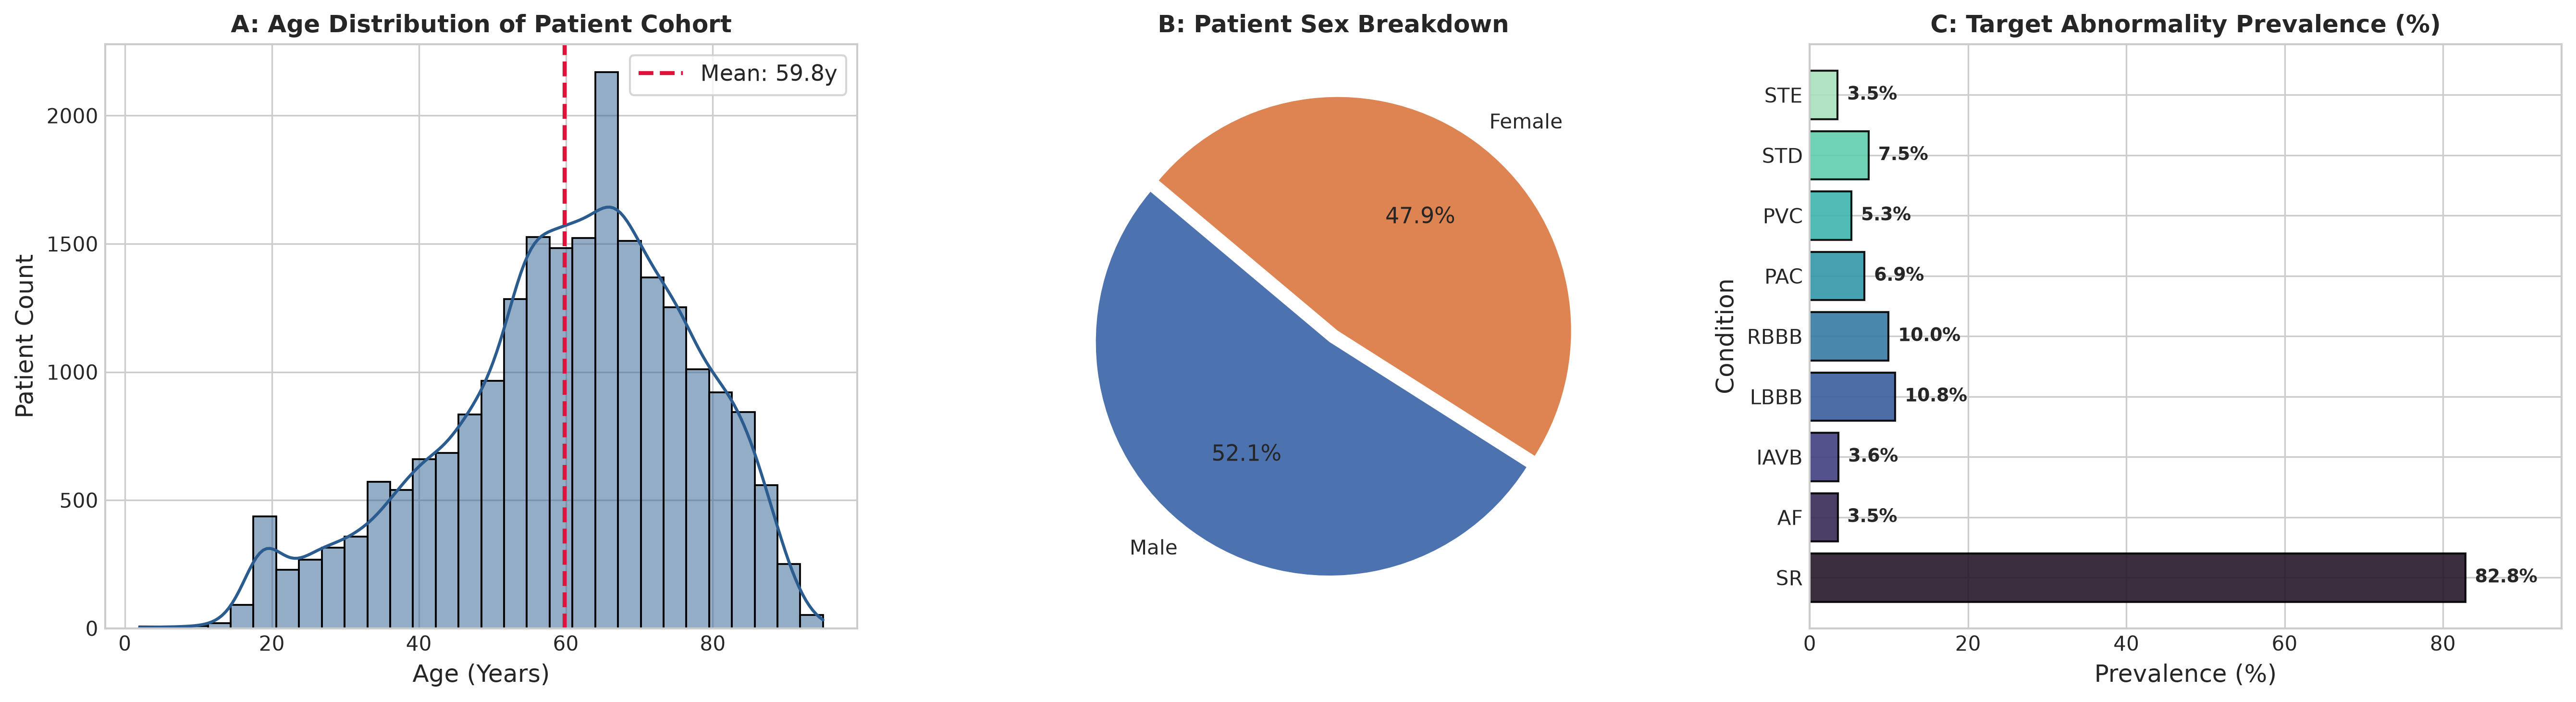

Figure 1 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig1_dataset_and_label_distribution.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot A: Age
sns.histplot(df_all['age'].dropna(), bins=30, kde=True, ax=axes[0], color='#2b5c8f', edgecolor='black')
axes[0].set_title('A: Age Distribution of Patient Cohort', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Patient Count')
axes[0].axvline(df_all['age'].mean(), color='crimson', linestyle='--', linewidth=2, label=f"Mean: {df_all['age'].mean():.1f}y")
axes[0].legend(loc='upper right', frameon=True)

# Subplot B: Sex
sex_counts = df_all['sex'].value_counts()
colors = ['#4c72b0', '#dd8452', '#55a868']
axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=[0.03]*len(sex_counts))
axes[1].set_title('B: Patient Sex Breakdown', fontweight='bold', fontsize=12)

# Subplot C: Abnormality Prevalence
palette = sns.color_palette("mako", len(target_cols))
bars = axes[2].barh(df_target_summary['Abbreviation'], df_target_summary['Prevalence (%)'], color=palette, edgecolor='black', alpha=0.9)
axes[2].set_title('C: Target Abnormality Prevalence (%)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Prevalence (%)')
axes[2].set_ylabel('Condition')
for bar in bars:
    w = bar.get_width()
    axes[2].text(w + 1.2, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va='center', ha='left', fontsize=9, fontweight='bold')
axes[2].set_xlim(0, 95)

plt.tight_layout()
fig1_path = os.path.join(FIG_DIR, "fig1_dataset_and_label_distribution.png")
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 1 saved to: {fig1_path}")


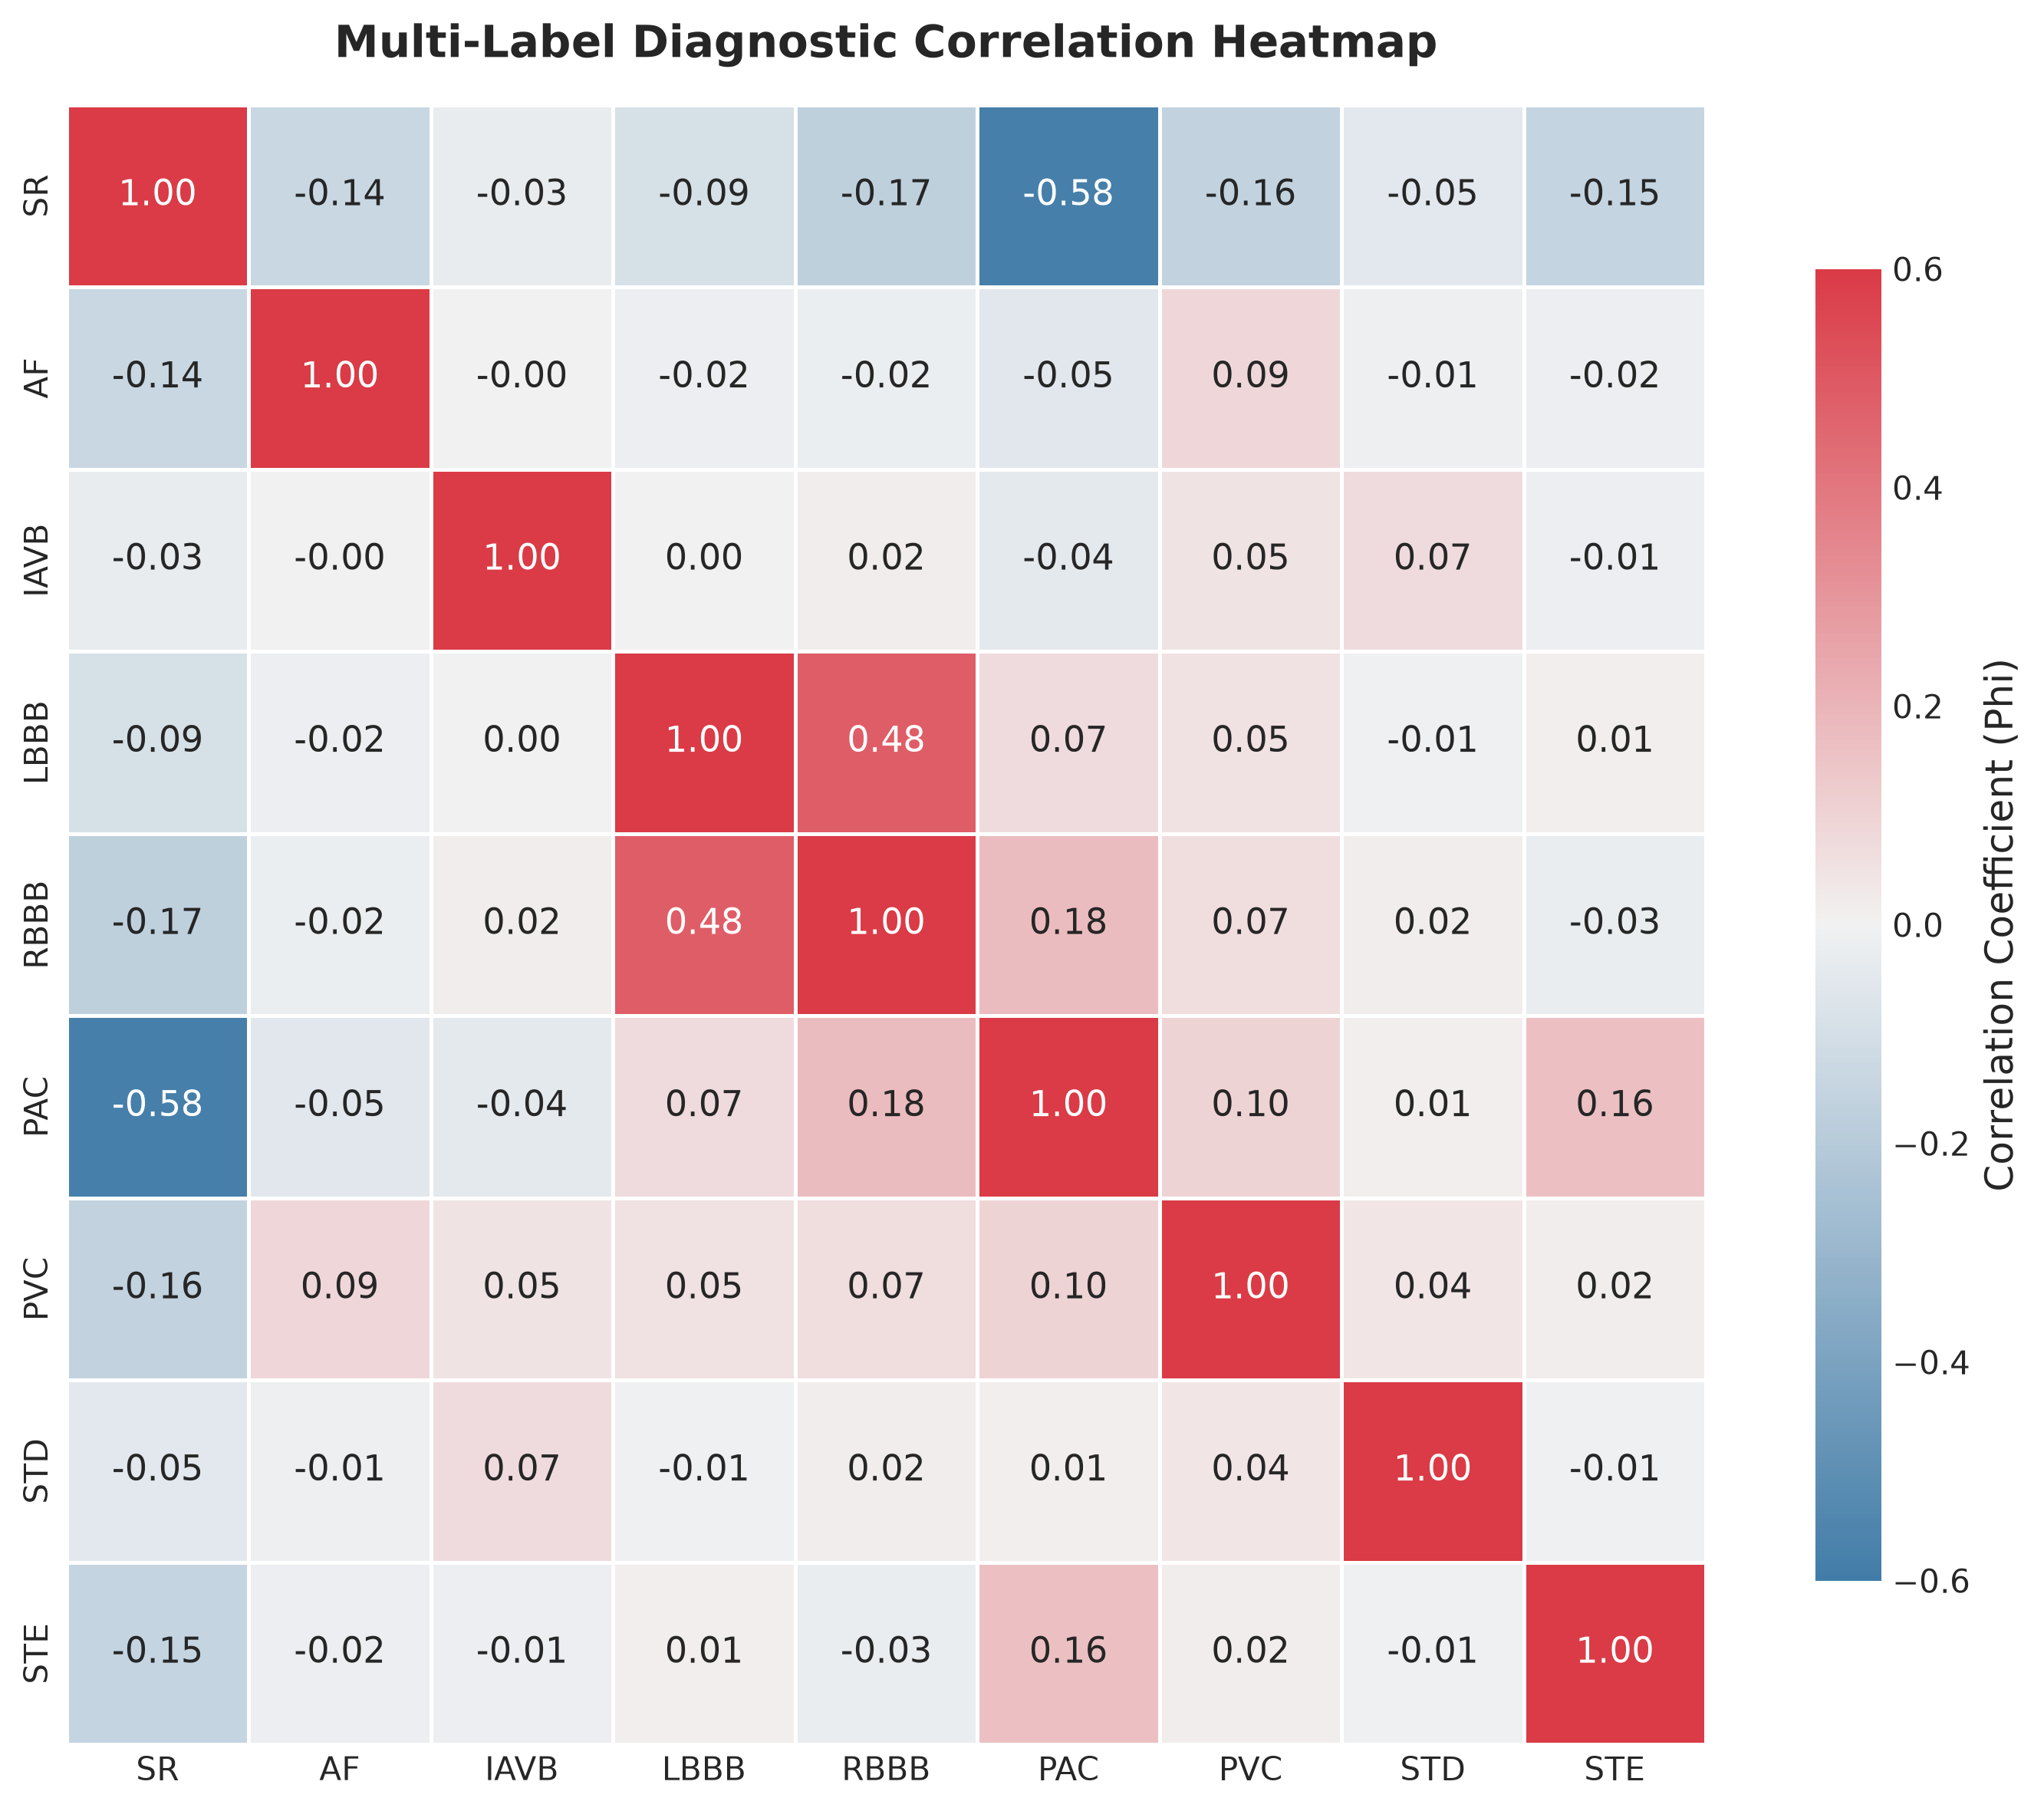

Figure 2 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig2_label_cooccurrence_matrix.png


In [8]:
corr_matrix = df_all[target_cols].corr()

plt.figure(figsize=(10, 8))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap, vmin=-0.6, vmax=0.6,
            square=True, linewidths=0.8, cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient (Phi)"})
plt.title('Multi-Label Diagnostic Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
fig2_path = os.path.join(FIG_DIR, "fig2_label_cooccurrence_matrix.png")
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 2 saved to: {fig2_path}")


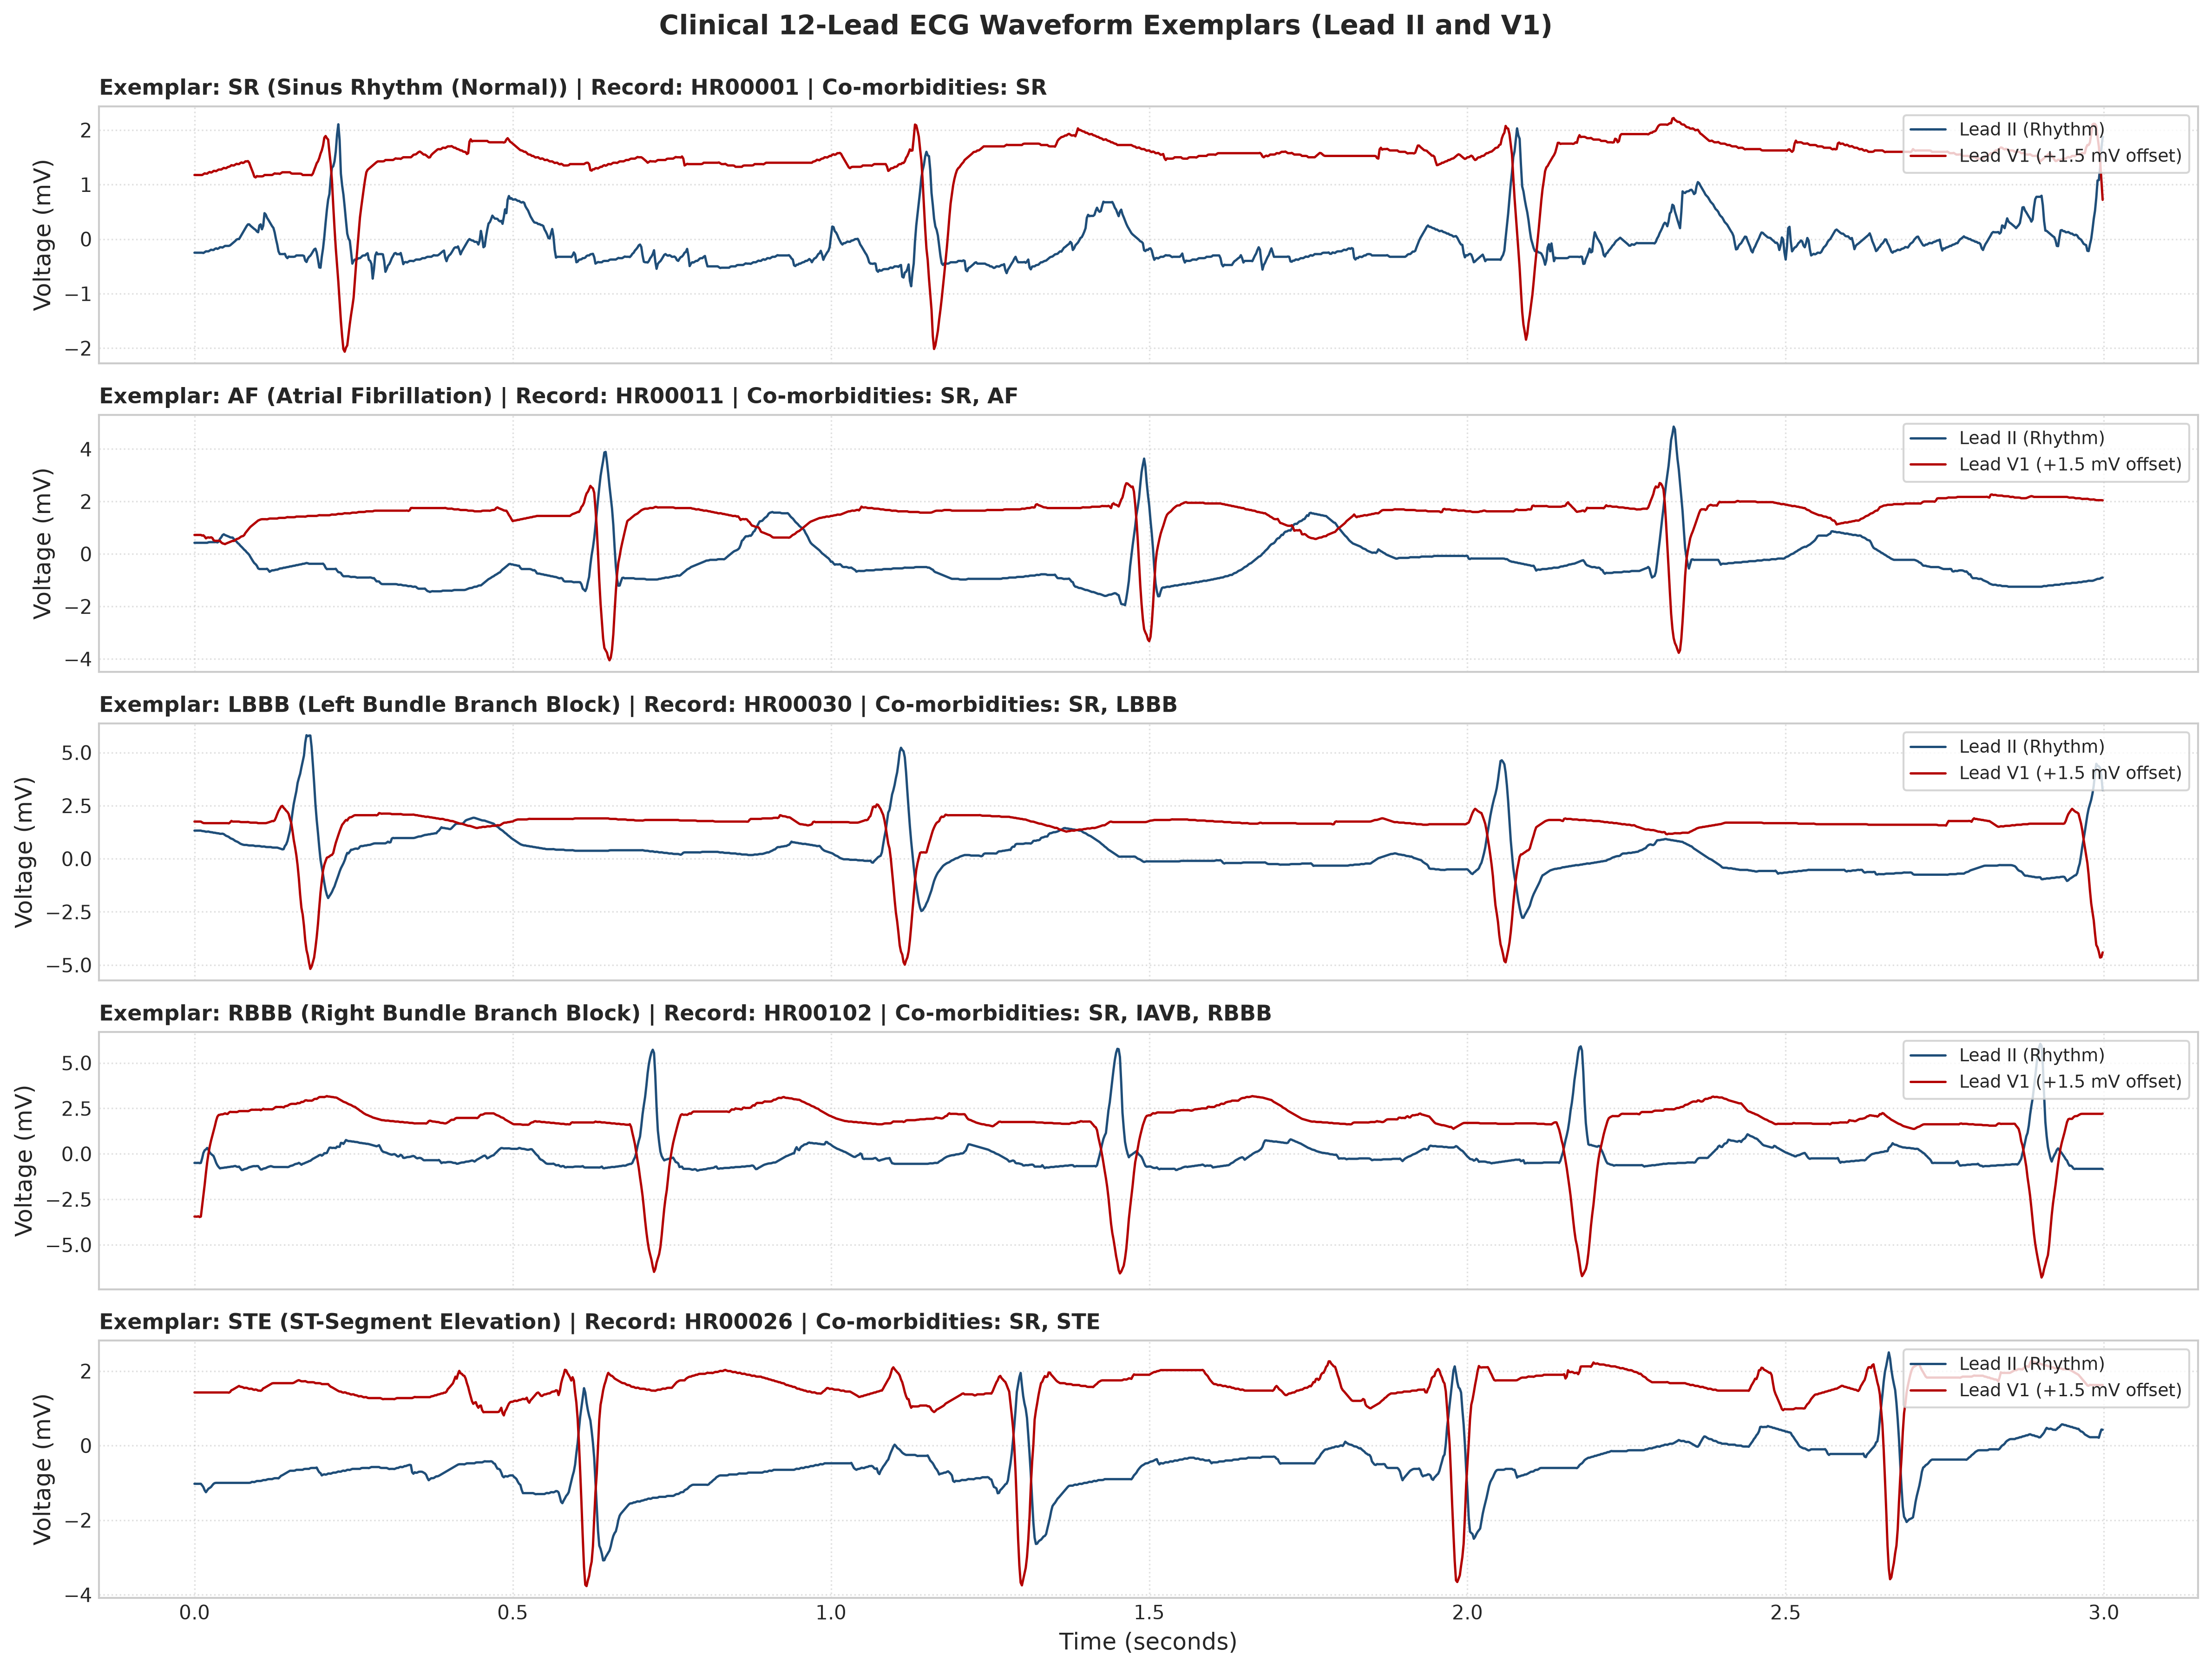

Figure 3 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig3_clinical_ecg_gallery.png


In [9]:
fs = 500
t_axis = np.arange(1500) / fs # First 3 seconds

exemplar_conditions = ['SR', 'AF', 'LBBB', 'RBBB', 'STE']
fig, axes = plt.subplots(len(exemplar_conditions), 1, figsize=(16, 12), sharex=True)

for i, cond in enumerate(exemplar_conditions):
    rec = df_all[df_all[cond] == 1].iloc[0]
    mat = sio.loadmat(rec['mat_path'])['val'] / 200.0 # Convert to mV
    
    axes[i].plot(t_axis, mat[1, :1500], label='Lead II (Rhythm)', color='#1f4e79', linewidth=1.2)
    axes[i].plot(t_axis, mat[6, :1500] + 1.5, label='Lead V1 (+1.5 mV offset)', color='#b30000', linewidth=1.2)
    
    active_dx = [c for c in target_cols if rec[c] == 1]
    axes[i].set_title(f"Exemplar: {cond} ({TARGET_CLASSES[cond]['name']}) | Record: {rec['rec_id']} | Co-morbidities: {', '.join(active_dx)}", 
                      fontweight='bold', fontsize=11, loc='left')
    axes[i].set_ylabel('Voltage (mV)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='upper right', frameon=True, fontsize=9)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Clinical 12-Lead ECG Waveform Exemplars (Lead II and V1)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
fig3_path = os.path.join(FIG_DIR, "fig3_clinical_ecg_gallery.png")
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 3 saved to: {fig3_path}")


In [10]:
audit_summary = {
    'Metric': [
        'Total ECG Records',
        'Total Unique Patients',
        'Leads per Record',
        'Sampling Frequency (Hz)',
        'Duration per Record (s)',
        'Total Samples per Lead',
        'Corrupted Records Detected',
        'Missing Values in Signals',
        'Target Abnormalities Defined',
        'Mean Label Cardinality',
        'Label Density',
        'Patients with Multi-Label Dx (>=2)',
        'Patients with Single Label Dx',
        'Patients with Normal SR Only'
    ],
    'Value': [
        f"{len(df_all):,}",
        f"{len(df_all):,}",
        "12 (I, II, III, aVR, aVL, aVF, V1-V6)",
        "500",
        "10.0",
        "5,000",
        "0 (0.00%)",
        "0 (0.00%)",
        f"{len(target_cols)}",
        f"{mean_card:.2f}",
        f"{mean_density:.3f}",
        f"{(df_all['target_cardinality'] >= 2).sum():,} ({(df_all['target_cardinality'] >= 2).mean()*100:.1f}%)",
        f"{(df_all['target_cardinality'] == 1).sum():,} ({(df_all['target_cardinality'] == 1).mean()*100:.1f}%)",
        f"{((df_all['SR'] == 1) & (df_all['target_cardinality'] == 1)).sum():,} ({((df_all['SR'] == 1) & (df_all['target_cardinality'] == 1)).mean()*100:.1f}%)"
    ]
}

df_audit_table = pd.DataFrame(audit_summary)
audit_csv = os.path.join(TAB_DIR, "dataset_audit_summary.csv")
df_audit_table.to_csv(audit_csv, index=False)
print("=== FINAL COMPREHENSIVE DATASET AUDIT SUMMARY ===")
print(df_audit_table.to_string(index=False))
print(f"\nExported audit summary table to: {audit_csv}")


=== FINAL COMPREHENSIVE DATASET AUDIT SUMMARY ===
                            Metric                                 Value
                 Total ECG Records                                21,837
             Total Unique Patients                                21,837
                  Leads per Record 12 (I, II, III, aVR, aVL, aVF, V1-V6)
           Sampling Frequency (Hz)                                   500
           Duration per Record (s)                                  10.0
            Total Samples per Lead                                 5,000
        Corrupted Records Detected                             0 (0.00%)
         Missing Values in Signals                             0 (0.00%)
      Target Abnormalities Defined                                     9
            Mean Label Cardinality                                  1.34
                     Label Density                                 0.149
Patients with Multi-Label Dx (>=2)                         6,335 (29.0%)
 